# Analisis de Biodiversidad en Parques Nacionales de Estados Unidos

Este proyecto explora los datos de biodiversidad del Servicio de Parques Nacionales (NPS) para analizar la distribucion de especies, su estado de conservacion y los patrones de observacion en cuatro parques nacionales.

**Objetivos:**
1. Analizar la distribucion del estado de conservacion entre especies
2. Identificar si ciertos tipos de especies tienen mayor riesgo de estar en peligro
3. Evaluar la biodiversidad y frecuencia de observacion por parque
4. Identificar las especies en peligro que necesitan monitoreo urgente
5. Preparar los datos para un futuro modelo de clasificacion

**Datasets:** Informacion de 5,824 especies y sus observaciones en 4 parques nacionales.

## 1. Importacion de Librerias y Datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
# Cargar datasets
observations = pd.read_csv('observations.csv')
species = pd.read_csv('species_info.csv')

print(f"Dataset de observaciones: {observations.shape[0]} registros, {observations.shape[1]} variables")
print(f"Dataset de especies: {species.shape[0]} registros, {species.shape[1]} variables")
print(f"\nDuplicados en observaciones: {observations.duplicated().sum()}")
print(f"Duplicados en especies: {species.duplicated().sum()}")

Dataset de observaciones: 23296 registros, 3 variables
Dataset de especies: 5824 registros, 4 variables

Duplicados en observaciones: 15


Duplicados en especies: 0


In [3]:
print("OBSERVACIONES:")
print(observations.head())
print("\nESPECIES:")
print(species.head())

OBSERVACIONES:
            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85

ESPECIES:
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  A

## 2. Exploracion Inicial

In [4]:
print("=" * 60)
print("INFORMACION DE LOS DATASETS")
print("=" * 60)
print(f"\nObservaciones: {observations.shape}")
print(f"  Parques: {observations['park_name'].nunique()} -> {list(observations['park_name'].unique())}")
print(f"  Especies unicas: {observations['scientific_name'].nunique()}")
print(f"\nEspecies: {species.shape}")
print(f"  Categorias: {list(species['category'].unique())}")
print(f"  Valores nulos en conservation_status: {species['conservation_status'].isnull().sum()} ({species['conservation_status'].isnull().mean()*100:.1f}%)")

INFORMACION DE LOS DATASETS

Observaciones: (23296, 3)
  Parques: 4 -> ['Great Smoky Mountains National Park', 'Yosemite National Park', 'Bryce National Park', 'Yellowstone National Park']
  Especies unicas: 5541

Especies: (5824, 4)
  Categorias: ['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish', 'Vascular Plant', 'Nonvascular Plant']
  Valores nulos en conservation_status: 5633 (96.7%)


In [5]:
# Llenar valores nulos como 'No Concern' (la mayoria de especies no estan en riesgo)
species['conservation_status'] = species['conservation_status'].fillna('No Concern')

# Ordenar categorias de conservacion
species['conservation_status'] = pd.Categorical(
    species['conservation_status'],
    categories=['No Concern', 'Species of Concern', 'Threatened', 'Endangered', 'In Recovery'],
    ordered=True
)

print("Distribucion del estado de conservacion:")
status_counts = species['conservation_status'].value_counts()
for status, count in status_counts.items():
    pct = count / len(species) * 100
    print(f"  {status:<22} {count:>5} ({pct:.1f}%)")

Distribucion del estado de conservacion:
  No Concern              5633 (96.7%)
  Species of Concern       161 (2.8%)
  Endangered                16 (0.3%)
  Threatened                10 (0.2%)
  In Recovery                4 (0.1%)


## 3. Distribucion del Estado de Conservacion

Analizamos como se distribuyen las especies segun su nivel de riesgo. La gran mayoria no presenta preocupaciones, pero un porcentaje significativo requiere atencion.

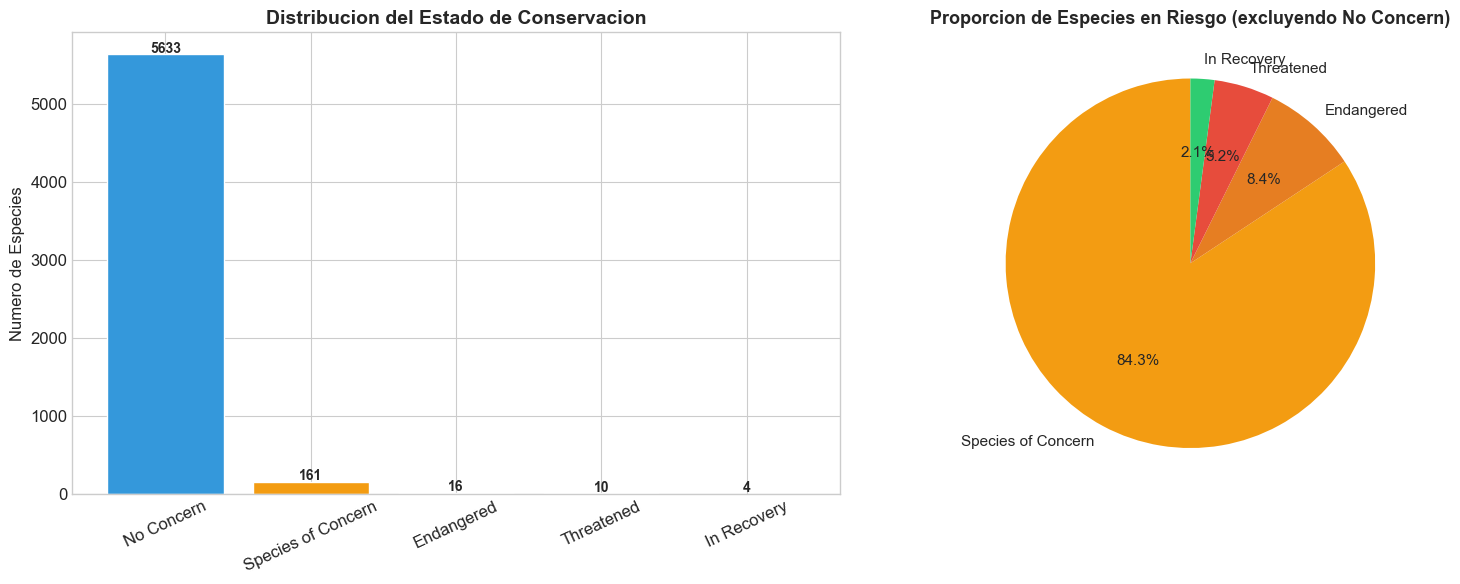

Total de especies en alguna categoria de riesgo: 191 (3.3%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
colors_status = ['#3498db', '#f39c12', '#e67e22', '#e74c3c', '#2ecc71']
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors_status, edgecolor='white')
axes[0].set_title('Distribucion del Estado de Conservacion', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Numero de Especies', fontsize=12)
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontsize=10, fontweight='bold')

# Pie chart (sin 'No Concern' para ver proporcion de especies en riesgo)
at_risk = status_counts[status_counts.index != 'No Concern']
axes[1].pie(at_risk.values, labels=at_risk.index, autopct='%1.1f%%',
           colors=colors_status[1:], startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporcion de Especies en Riesgo (excluyendo No Concern)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

total_risk = at_risk.sum()
print(f"Total de especies en alguna categoria de riesgo: {total_risk} ({total_risk/len(species)*100:.1f}%)")

## 4. Relacion entre Tipo de Especie y Estado de Conservacion

Investigamos si ciertos tipos de organismos (mamiferos, aves, plantas, etc.) tienen mayor probabilidad de estar en peligro. Utilizamos un test Chi-cuadrado para evaluar la significancia estadistica.

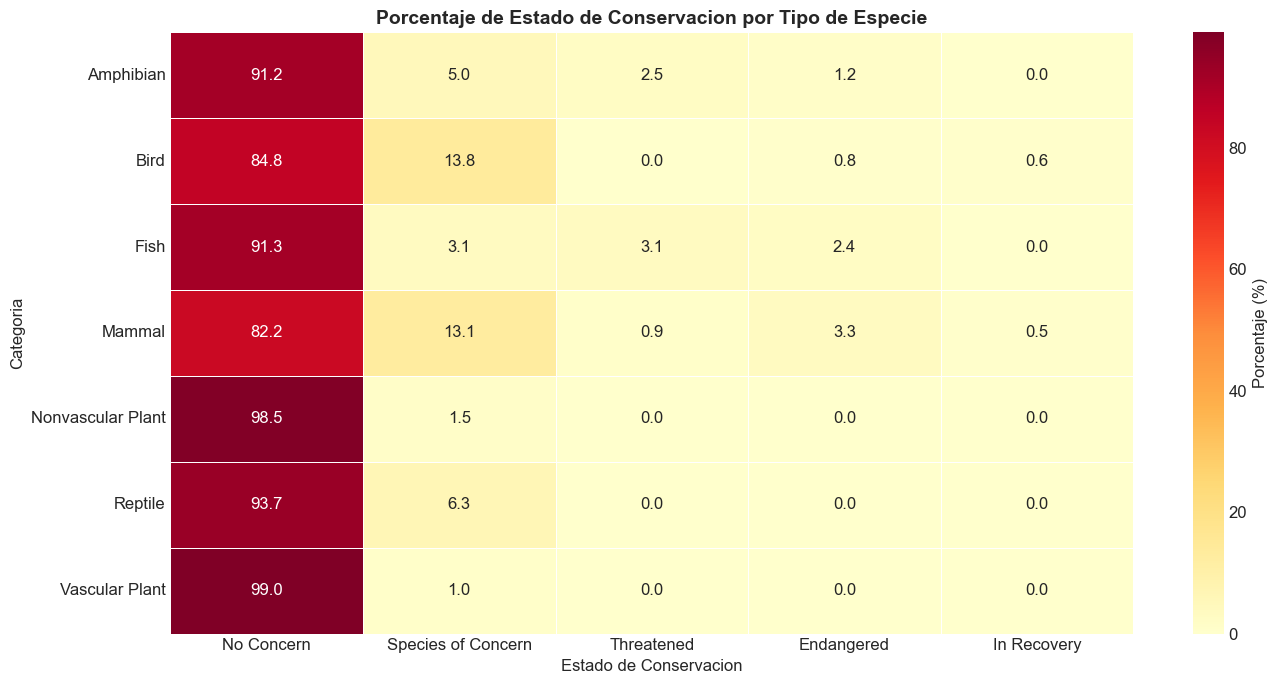

In [7]:
# Tabla cruzada: categoria vs estado de conservacion
counts = species.groupby(['category', 'conservation_status'], observed=False)['scientific_name'].count().reset_index()
counts.columns = ['category', 'conservation_status', 'counts']

# Pivot para porcentajes
categoric_status = counts.pivot(columns='conservation_status', index='category', values='counts').fillna(0)

# Calcular porcentajes por fila
percent_status = categoric_status.div(categoric_status.sum(axis=1), axis=0) * 100

# Heatmap
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(percent_status, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Porcentaje (%)'})
ax.set_title('Porcentaje de Estado de Conservacion por Tipo de Especie', fontsize=14, fontweight='bold')
ax.set_ylabel('Categoria', fontsize=12)
ax.set_xlabel('Estado de Conservacion', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# Test Chi-cuadrado
contingency = pd.crosstab(species['category'], species['conservation_status'])
chi2, pval, dof, expected = chi2_contingency(contingency)

print("=" * 55)
print("TEST CHI-CUADRADO DE INDEPENDENCIA")
print("=" * 55)
print(f"  Chi²: {chi2:.2f}")
print(f"  p-value: {pval:.2e}")
print(f"  Grados de libertad: {dof}")
print(f"\n  Resultado: {'Rechazamos H0' if pval < 0.05 else 'No rechazamos H0'} (alpha = 0.05)")
print("  Existe una relacion significativa entre el tipo de especie")
print("  y su estado de conservacion.")
print("\n  Las Aves y Mamiferos representan el 100% de las especies 'In Recovery',")
print("  mientras que las Plantas Vasculares dominan la categoria 'No Concern'.")

TEST CHI-CUADRADO DE INDEPENDENCIA
  Chi²: 628.58
  p-value: 2.46e-117
  Grados de libertad: 24

  Resultado: Rechazamos H0 (alpha = 0.05)
  Existe una relacion significativa entre el tipo de especie
  y su estado de conservacion.

  Las Aves y Mamiferos representan el 100% de las especies 'In Recovery',
  mientras que las Plantas Vasculares dominan la categoria 'No Concern'.


## 5. Biodiversidad por Parque Nacional

Analizamos la diversidad de especies y la frecuencia de observaciones en cada uno de los cuatro parques nacionales.

In [9]:
# Merge de datasets
df = pd.merge(species, observations, on='scientific_name')

# Resumen por parque
species_per_park = df.groupby('park_name')['scientific_name'].nunique()
obs_per_park = df.groupby('park_name')['observations'].sum()
mean_obs = df.groupby('park_name')['observations'].mean()

summary = pd.DataFrame({
    'Especies Unicas': species_per_park,
    'Total Observaciones': obs_per_park,
    'Media Obs/Especie': mean_obs.round(1)
})

print("=" * 65)
print("BIODIVERSIDAD POR PARQUE NACIONAL")
print("=" * 65)
print(summary.to_string())

BIODIVERSIDAD POR PARQUE NACIONAL
                                     Especies Unicas  Total Observaciones  Media Obs/Especie
park_name                                                                                   
Bryce National Park                             5541               633291               98.8
Great Smoky Mountains National Park             5541               474863               74.1
Yellowstone National Park                       5541              1587641              247.8
Yosemite National Park                          5541               949452              148.2


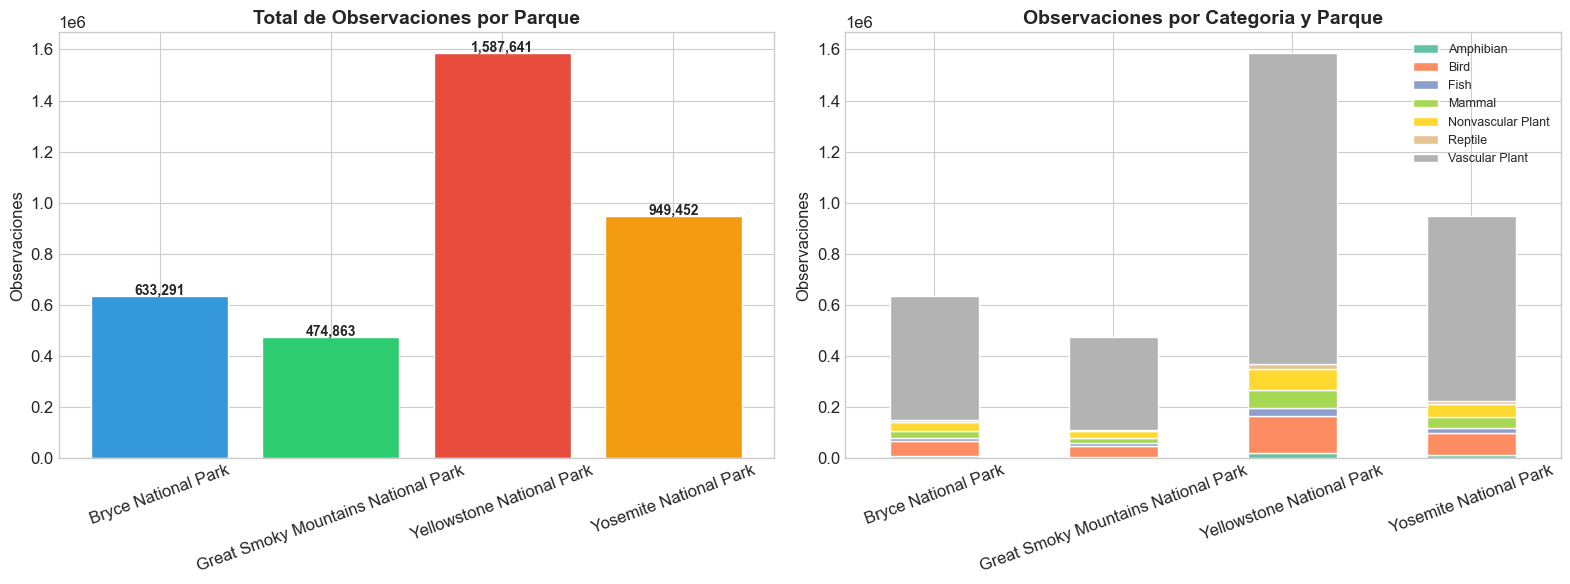

Los 4 parques comparten las mismas 5,541 especies.
La diferencia en biodiversidad radica en la frecuencia de observacion:
Yellowstone lidera con ~1.6M observaciones totales.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Observaciones por parque
colors_parks = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars1 = axes[0].bar(obs_per_park.index, obs_per_park.values, color=colors_parks, edgecolor='white')
axes[0].set_title('Total de Observaciones por Parque', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Observaciones', fontsize=12)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars1, obs_per_park.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Observaciones por categoria y parque
cat_park = df.groupby(['park_name', 'category'])['observations'].sum().reset_index()
cat_pivot = cat_park.pivot(index='park_name', columns='category', values='observations')
cat_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Observaciones por Categoria y Parque', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Observaciones', fontsize=12)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print("Los 4 parques comparten las mismas 5,541 especies.")
print("La diferencia en biodiversidad radica en la frecuencia de observacion:")
print("Yellowstone lidera con ~1.6M observaciones totales.")

## 6. Especies en Peligro: Monitoreo Urgente

Identificamos las especies amenazadas o en peligro con menor numero de observaciones, ya que son las mas dificiles de encontrar y potencialmente las mas vulnerables.

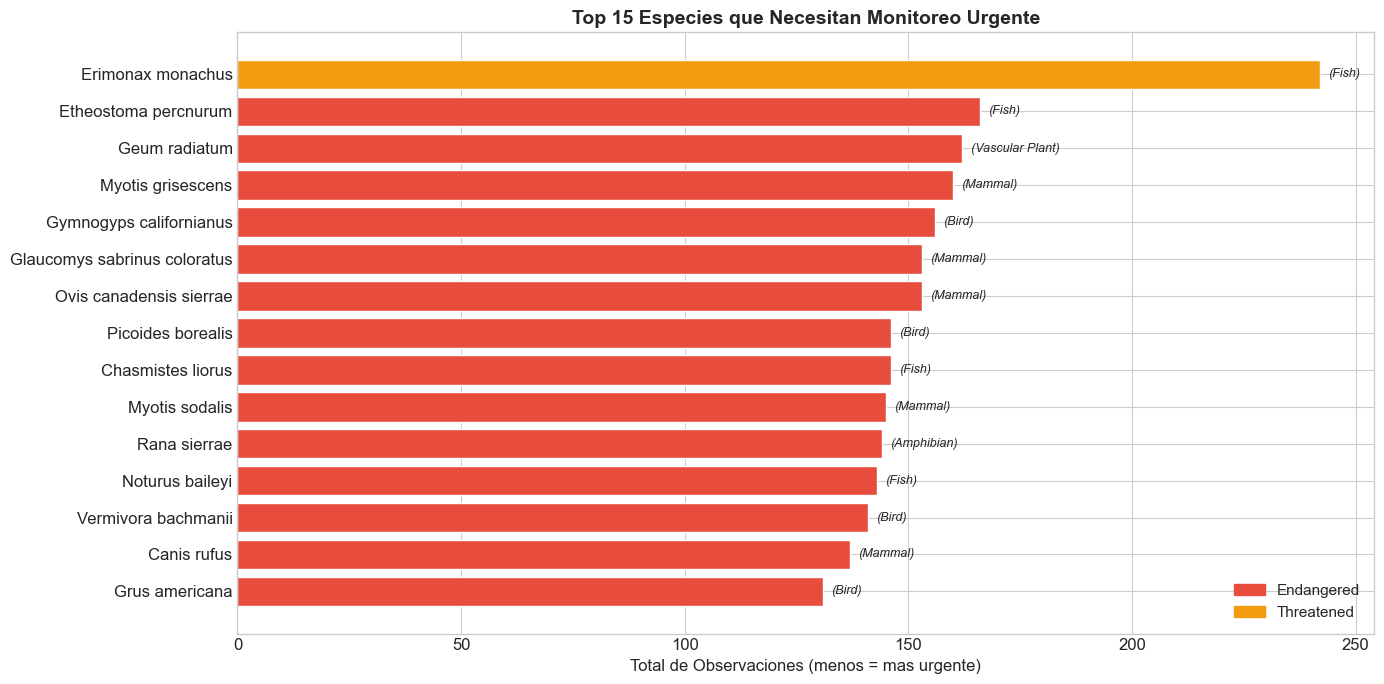

Las especies con menor numero de observaciones son las mas dificiles
de monitorear y potencialmente las mas vulnerables a la extincion.


In [11]:
# Filtrar especies en riesgo
species_risk = df[(df['conservation_status'] == 'Threatened') | (df['conservation_status'] == 'Endangered')]

# Top 15 especies mas urgentes (menores observaciones)
urgent = species_risk.groupby(
    ['scientific_name', 'category', 'conservation_status'], observed=True
)['observations'].sum().reset_index()
urgent = urgent.sort_values('observations').head(15)

fig, ax = plt.subplots(figsize=(14, 7))
colors_urgent = ['#e74c3c' if s == 'Endangered' else '#f39c12' for s in urgent['conservation_status']]
bars = ax.barh(urgent['scientific_name'], urgent['observations'], color=colors_urgent, edgecolor='white')
ax.set_title('Top 15 Especies que Necesitan Monitoreo Urgente', fontsize=14, fontweight='bold')
ax.set_xlabel('Total de Observaciones (menos = mas urgente)', fontsize=12)

# Agregar categoria
for bar, cat in zip(bars, urgent['category']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'({cat})', va='center', fontsize=9, style='italic')

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#e74c3c', label='Endangered'),
    plt.Rectangle((0,0),1,1, color='#f39c12', label='Threatened')
], fontsize=11)
plt.tight_layout()
plt.show()

print("Las especies con menor numero de observaciones son las mas dificiles")
print("de monitorear y potencialmente las mas vulnerables a la extincion.")

## 7. Preparacion de Datos para Machine Learning

Preparamos las features para un futuro modelo de clasificacion que prediga el estado de conservacion de una especie basandose en sus caracteristicas.

In [12]:
# Variable objetivo binaria
species['is_protected'] = (species['conservation_status'] != 'No Concern').astype(int)

# One-hot encoding de categorias
category_dummies = pd.get_dummies(species['category'], prefix='cat')
species_ml = pd.concat([species, category_dummies], axis=1)

# Features numericas del nombre
species_ml['name_count'] = species_ml['common_names'].str.count(',') + 1
species_ml['name_length'] = species_ml['scientific_name'].str.len()

# Agregar observaciones totales
obs_totals = observations.groupby('scientific_name')['observations'].sum().reset_index()
obs_totals.columns = ['scientific_name', 'total_observations']
species_ml = species_ml.merge(obs_totals, on='scientific_name', how='left')
species_ml['total_observations'] = species_ml['total_observations'].fillna(0)

# Features finales
feature_cols = [c for c in species_ml.columns if c.startswith('cat_')] + ['name_count', 'name_length', 'total_observations']
print(f"Features preparadas: {len(feature_cols)}")
for f in feature_cols:
    print(f"  - {f}")
print(f"\nVariable objetivo: is_protected")
print(f"  Protegidas: {species_ml['is_protected'].sum()} ({species_ml['is_protected'].mean()*100:.1f}%)")
print(f"  No protegidas: {(species_ml['is_protected']==0).sum()} ({(species_ml['is_protected']==0).mean()*100:.1f}%)")

species_ml[feature_cols + ['is_protected']].head(10)

Features preparadas: 10
  - cat_Amphibian
  - cat_Bird
  - cat_Fish
  - cat_Mammal
  - cat_Nonvascular Plant
  - cat_Reptile
  - cat_Vascular Plant
  - name_count
  - name_length
  - total_observations

Variable objetivo: is_protected
  Protegidas: 191 (3.3%)
  No protegidas: 5633 (96.7%)


,cat_Amphibian,cat_Bird,cat_Fish,cat_Mammal,cat_Nonvascular Plant,cat_Reptile,cat_Vascular Plant,name_count,name_length,total_observations,is_protected
0,False,False,False,True,False,False,False,1,29,615,0
1,False,False,False,True,False,False,False,2,9,542,0
2,False,False,False,True,False,False,False,4,10,514,0
3,False,False,False,True,False,False,False,4,10,542,0
4,False,False,False,True,False,False,False,1,14,1218,0
5,False,False,False,True,False,False,False,1,22,1061,0
6,False,False,False,True,False,False,False,2,10,1166,0
7,False,False,False,True,False,False,False,1,13,458,1
8,False,False,False,True,False,False,False,1,11,715,1
9,False,False,False,True,False,False,False,1,11,137,1


## 8. Conclusiones

### Hallazgos principales

1. **Estado de conservacion:** El 96.7% de las especies no presenta preocupaciones de conservacion. Solo el 3.3% esta en alguna categoria de riesgo, pero estas son las que requieren mayor atencion.

2. **Sesgo taxonomico en conservacion:** Existe una relacion estadisticamente significativa (Chi² = 628.58, p < 0.001) entre el tipo de especie y su estado de conservacion. Las Aves y Mamiferos representan el 100% de las especies "In Recovery", mientras que las Plantas Vasculares dominan la categoria "No Concern".

3. **Biodiversidad por parque:** Los 4 parques comparten las mismas 5,541 especies. La diferencia radica en la frecuencia de observacion: Yellowstone lidera con ~1.6M observaciones, lo que sugiere un ecosistema mas activo o mejor monitoreado.

4. **Monitoreo urgente:** Las especies con menos observaciones (como Grus americana y Canis rufus) son las mas criticas. Pocas observaciones pueden indicar poblaciones extremadamente reducidas.

5. **Preparacion ML:** Se generaron 10 features para un futuro modelo de clasificacion, incluyendo categorias taxonomicas, caracteristicas del nombre cientifico y frecuencia de observacion.

---
*Analisis de biodiversidad basado en datos del National Park Service (NPS), 4 parques nacionales, 5,824 especies.*